# Mejoras — Intención: Integración de datos reales (v3)

Continúa de `Mejoras_Intencion_FineTuning_BETO_v2.ipynb`. Se exploraron
fuentes públicas (Q&A de MercadoLibre, reseñas de Google) para ampliar el
corpus de intención con datos reales, pero el registro de chat en primera
persona (lo que necesita este modelo) es inherentemente privado — no está
indexado públicamente. Se optó por **crowdsourcing**: se le pidió al
integrante del proyecto que escribiera mensajes reales, sin ver el dataset
existente (para no contaminar el estilo), como si le escribiera a una tienda
de accesorios/reparación Apple por WhatsApp.

Resultado: **143 mensajes reales**, cubriendo 7 de las 8 clases (falta
`saludo_cierre`, la clase mejor resuelta, no crítico).

In [1]:
import os
import re
import numpy as np
import pandas as pd
import joblib
import torch
import random
import matplotlib.pyplot as plt
from datasets import Dataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from xgboost import XGBClassifier
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, DataCollatorWithPadding,
)

BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
DATA_DIR = os.path.join(BASE_DIR, "..", "data")
MODELOS_DIR = os.path.join(BASE_DIR, "app", "modelos")
FIGURAS_DIR = os.path.join(BASE_DIR, "resultados", "figuras")
RANDOM_STATE = 42
MODEL_NAME = "dccuchile/bert-base-spanish-wwm-cased"
random.seed(21)


In [2]:
DATOS_REALES = {
    "consulta_producto": [
        "Que marcas de celulares tiene?", "cuales son las caracteristicas de la MacBook Air",
        "que tipo de accesorios hay para mi celular?", "dispone de cargadores MagSafe?",
        "que clase de fundas hay para mi iPhone 16 Pro Max", "que modelos de mac tiene?",
        "estoy buscando un celular de gama alta", "dispone del nuevo modelo de iPhone?",
        "vende alguna marca de Apple Watch?", "que tipo de marcas tiene?",
        "puedo ver sus modelitos?", "estoy buscando esta marca de celular",
        "tiene disponible la ultima version del MacBooks Air", "que especificaciones tiene ese modelito?",
        "que tipo de productos tiene disponible?", "puede recomendarme algun producto?",
        "tiene el iPad estandar? que tipo de modelitos?", "tiene algunas fundas para mi compra?",
        "que clase de accesorios tiene mi modelo?", "que tipo de protectores de pantalla tiene? para mi celular?",
    ],
    "consulta_precio": [
        "cuanto cuesta esas fundas?", "cual es el precio del nuevo iPhone?",
        "y cuanto cuesta el cargador MagSafe?", "puede mencionarme el precio?",
        "pueda hablarme sobre el costo de los nuevos modelos de Mac",
        "Si compro dos productos, recibire algun descuento? cuanto seria en total?",
        "con todos sus accesorios, puede decirme el total.", "y cuanto me costaria en total?",
        "puede mandarme los precios de los otros productos?", "esa funda para mi celular, cuanto esta?",
        "y el mas economico?", "el mas caro?", "al final, recibire algun descuento? cuanto seria?",
        "cuanto seria si compro mas de un producto?", "cual es el precio de ese modelo de ordenador?",
        "cuanto cuesta?", "puede mandarme los precios tambien?", "quisiera saber los costos del producto",
        "entonces este producto cuesta asi?", "ese es el precio mas economico?",
        "puede enviarle el catalago? con los precios porfavor",
    ],
    "consulta_servicio_tecnico": [
        "mi nuevo producto fallo, pueden revisarlo?", "disculpe mi equipo dejo de funcionar pueden verlo?",
        "ocurrio un problema con mi compra, quisiera saber si se puede arreglar",
        "alguno de ustedes puede solucionar la falla de mi nuevo celular?",
        "se rompio la pantalla, quisiera saber si pueden ayudarme",
        "no se que paso, dejo de funcionar, pueden revisar el equipo?",
        "pueden revisarlo? la carga dejo de trabajar y ya no funciona",
        "se cayo accidentalmente, pueden revisarlo?", "tiene solucion? se rompio su pantalla",
        "quisiera saber si pueden solucionar el problema", "pueden ayudarme?",
        "puedo llevarlo? para que lo revisen?", "ultimamente estuvo lenta, pueden revisarlo?",
        "se le cayo un poco de agua, y no funciona, se puede arreglar?", "sabe si se puede correguir?",
        "se puede arreglar mi producto?", "pueden revisarlo?", "es capas de ser arreglado",
        "puedo llevarselos para que lo revisen?",
    ],
    "queja_producto_servicio": [
        "Pesima atencion, no me enviaron la marca que dije", "Mi producto llego roto?",
        "No funciona, no hice nada", "De la nada dejo de prender su pantalla",
        "Pueden decirme porque no llego el producto que compre? llego otro producto",
        "Lo use por un dia, y dejo de funcionar", "De la nada se apago que paso? porque no funciona?",
        "No prende, apenas lo compre ayer", "Llego danado", "me lo entregaron sin funcionar, no prende",
        "Ni siquiera anotaron bien mi producto, me entregaron cualquier cosa",
        "como es posible que ni siquiera lo he usado una semana y ya no funciona?",
        "no funciona", "llego roto", "se apago, y no prende", "dejo de funcionar",
        "despues de dos dias de uso dejo de funcionar", "no prende por alguna razon",
        "me entregaron otro producto", "esta no es la marca que pedi", "no compre esto",
        "se equivocaron no solicite esto",
    ],
    "solicitud_garantia_cambio": [
        "Necesito que cambien este producto", "Voy a devolverlo", "No funcionar, quiero que me lo cambien",
        "llego en mal estado, necesito otro producto, cambienmelo", "Esta roto, lo voy a devolver",
        "pienso devolverlo", "funciona pesimo, lo devolvere", "no cumple con lo que dijeron, quiero que lo cambien",
        "pueden cambiarmelo? dejo de funcionar", "necesito que cambien mi modelo",
        "voy a devolver, no es lo que pedi", "necesito devolver esto", "cambienmelo porque no es lo que esperaba",
        "exijo un cambio", "necesito que me cambien mi compra", "no es lo que buscaba voy a devolverlo",
        "tiene ciertos problemas, lo estoy devolviendo", "no funciona, lo devolvere",
        "llego otra cosa, necesito que me cambien con lo que compre", "ni siquiera prendio, lo devolvere",
        "me llego roto, cambienme el modelo",
    ],
    "seguimiento_reparacion": [
        "Hola, ya esta mi producto?", "como se encuentra mi producto?", "ya puede funcionar?",
        "cuanto se demoraran en arreglarlo?", "ya terminaron de repararlo?", "como van? ya identificaron el problema?",
        "cuanto tiempo mas les demorara arreglarlo?", "ya se soluciono? como van las reparaciones?",
        "ya esta reparado?", "la reparacion, como va? cuanto tiempo mas necesitaran?", "ya esta funcionando?",
        "ya comenzo a prender? se soluciono?", "arreglar su pantalla?", "se puedo corregir el error?",
        "como van, puedo saber si ya se resolvio?", "se corrigio o todavia no", "todavia no se corrige?",
        "como van las cosas, ya pudieron arreglarlo?", "se logro corregir las fallas?",
        "ya esta bien? se soluciono el problema?",
    ],
    "escalamiento_urgente": [
        "Me urge hablar con alguien ahora mismo", "Contactame con alguien",
        "Ya me canse de esperar, necesito hablar con alguien ahora mismo",
        "Puede llamar a alguien? que si me pueda ayudar?",
        "No entiendo? no existe alguien que pueda solucionar mi problema?",
        "puedo porfavor hablar con alguna persona?", "llego mucho tiempo esperando, contactame con alguna persona",
        "necesito un supervisor ahora mismo", "en este momento, contactame con alguien",
        "ya pase demasiado, no puedo seguir asi. Llame a alguien ahora mismo",
        "en este preciso momento necesito que me contacte tu supervisor",
        "solo llama a una persona que sepa ayudarme", "solo necesito que tu supervisor me responda",
        "enserio no pueden ayudarme? contacta a alguien ahora mismo", "es urgente puedes pasarme con tu supervisor?",
        "puedo al menos contactar con alguna persona?", "puedo por lo menos saber si algun dia una persona me ayudara?",
        "piensan ayudarme o no? me canse, necesito que me contactes con tu supervisor ahora mismo",
        "en este preciso momento no puedo seguir asi, llama a alguien",
        "llamalo ahora mismo, necesito a alguien que si sepa ayudarme",
    ],
}
total = sum(len(v) for v in DATOS_REALES.values())
print(f"Mensajes reales recibidos: {total}, en {len(DATOS_REALES)} clases")
for k, v in DATOS_REALES.items():
    print(f"  {k:30s} {len(v)}")


Mensajes reales recibidos: 143, en 7 clases
  consulta_producto              20
  consulta_precio                21
  consulta_servicio_tecnico      19
  queja_producto_servicio        22
  solicitud_garantia_cambio      21
  seguimiento_reparacion         20
  escalamiento_urgente           20


## 1. Split train / holdout real (80% / 20% por clase)

El holdout se separa **antes** de tocar nada más y no se usa para entrenar
ningún modelo — es la validación más confiable de todo el proyecto, porque
es texto humano real nunca visto.

In [3]:
train_reales, holdout_reales = [], []
for clase, mensajes in DATOS_REALES.items():
    mensajes = list(mensajes)
    random.shuffle(mensajes)
    n_holdout = max(3, round(len(mensajes) * 0.2))
    holdout_reales += [(m, clase) for m in mensajes[:n_holdout]]
    train_reales += [(m, clase) for m in mensajes[n_holdout:]]

print(f"Train real: {len(train_reales)}   Holdout real: {len(holdout_reales)}")

df_holdout = pd.DataFrame(holdout_reales, columns=["texto", "intencion"])
df_holdout.to_csv(os.path.join(DATA_DIR, "intenciones_holdout_real.csv"), index=False)

df_v2 = pd.read_csv(os.path.join(DATA_DIR, "intenciones_dataset_v2.csv"))
df_v3 = pd.concat([df_v2, pd.DataFrame(train_reales, columns=["texto", "intencion"])], ignore_index=True)
df_v3 = df_v3.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
df_v3.to_csv(os.path.join(DATA_DIR, "intenciones_dataset_v3.csv"), index=False)
print(f"\nCorpus v3 (v2 + reales de train): {len(df_v3)} mensajes")
print(df_v3["intencion"].value_counts())


Train real: 115   Holdout real: 28

Corpus v3 (v2 + reales de train): 679 mensajes
intencion
consulta_precio              105
consulta_servicio_tecnico    100
seguimiento_reparacion        97
consulta_producto             87
solicitud_garantia_cambio     86
queja_producto_servicio       82
escalamiento_urgente          70
saludo_cierre                 52
Name: count, dtype: int64


## 2. Reentrenar modelos clásicos sobre el corpus v3

In [4]:
ACENTOS = str.maketrans("áéíóú", "aeiou")
STOPWORDS_ES = {
    'de', 'la', 'el', 'en', 'y', 'a', 'que', 'los', 'se', 'del', 'las', 'un', 'por',
    'una', 'con', 'no', 'es', 'su', 'al', 'lo', 'mas', 'pero', 'si', 'como', 'me',
    'le', 'mi', 'muy', 'este', 'esta', 'ya', 'tambien', 'hay', 'para', 'son', 'fue',
    'todo', 'bien', 'cuando', 'sobre', 'sin', 'han', 'he', 'o', 'e', 'ni',
    'era', 'ser', 'tiene', 'habia', 'sus', 'mismo', 'tan', 'asi',
    'unos', 'desde', 'porque', 'hasta', 'te', 'les', 'nos', 'yo', 'tu', 'tus'
}

def limpiar_texto(texto):
    texto = str(texto).lower().translate(ACENTOS)
    texto = re.sub(r"[^a-zñ ]", " ", texto)
    palabras = [w for w in texto.split() if w not in STOPWORDS_ES and len(w) > 2]
    return " ".join(palabras)

df_v3["texto_limpio"] = df_v3["texto"].apply(limpiar_texto)
vec_v3 = TfidfVectorizer(max_features=1500, ngram_range=(1, 2), min_df=1)
X_v3 = vec_v3.fit_transform(df_v3["texto_limpio"])
y_v3 = df_v3["intencion"].to_numpy()
le_v3 = LabelEncoder()
y_v3_int = le_v3.fit_transform(y_v3)

modelos_v3 = {
    "logreg": LogisticRegression(class_weight="balanced", max_iter=1000, solver="saga", random_state=RANDOM_STATE).fit(X_v3, y_v3),
    "naive_bayes": MultinomialNB().fit(X_v3, y_v3),
    "svm": CalibratedClassifierCV(LinearSVC(class_weight="balanced", random_state=RANDOM_STATE), cv=3).fit(X_v3, y_v3),
    "xgboost": XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, eval_metric="logloss", random_state=RANDOM_STATE).fit(X_v3, y_v3_int),
}
for nombre, clf in modelos_v3.items():
    joblib.dump(clf, os.path.join(MODELOS_DIR, f"fonazo_{nombre}.joblib"))
joblib.dump(vec_v3, os.path.join(MODELOS_DIR, "fonazo_vectorizer.joblib"))
joblib.dump(le_v3, os.path.join(MODELOS_DIR, "fonazo_label_encoder_xgb.joblib"))
print("4 modelos clásicos v3 entrenados y guardados.")


4 modelos clásicos v3 entrenados y guardados.


## 3. Fine-tuning BETO v3 (corpus v2 + datos reales)

In [5]:
df_v3_beto = df_v3.copy()
le_beto3 = LabelEncoder()
df_v3_beto["label"] = le_beto3.fit_transform(df_v3_beto["intencion"])
train_df3, dev_df3 = train_test_split(df_v3_beto, test_size=0.15, stratify=df_v3_beto["label"], random_state=RANDOM_STATE)

tokenizer3 = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize3(batch):
    return tokenizer3(batch["texto"], truncation=True, padding="max_length", max_length=48)

train_ds3 = Dataset.from_pandas(train_df3[["texto", "label"]]).map(tokenize3, batched=True)
dev_ds3 = Dataset.from_pandas(dev_df3[["texto", "label"]]).map(tokenize3, batched=True)

modelo_beto_v3 = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=len(le_beto3.classes_))

def compute_metrics3(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {"accuracy": accuracy_score(labels, preds), "f1_macro": f1_score(labels, preds, average="macro")}

args3 = TrainingArguments(
    output_dir="_ckpt_tmp3", num_train_epochs=8, per_device_train_batch_size=16,
    per_device_eval_batch_size=32, learning_rate=2e-5, fp16=True,
    eval_strategy="epoch", save_strategy="no", logging_strategy="epoch",
    report_to=[], seed=RANDOM_STATE,
)
trainer3 = Trainer(
    model=modelo_beto_v3, args=args3, train_dataset=train_ds3, eval_dataset=dev_ds3,
    processing_class=tokenizer3, data_collator=DataCollatorWithPadding(tokenizer3),
    compute_metrics=compute_metrics3,
)
trainer3.train()


Map:   0%|          | 0/577 [00:00<?, ? examples/s]

Map:   0%|          | 0/102 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
bert.pooler.dense.bias                     | MISSING    | 
classifier.bias                            | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,1.714068,1.248155,0.715686,0.712552
2,0.892974,0.539821,0.911765,0.903065
3,0.336104,0.230077,0.950980,0.945214
4,0.119379,0.143370,0.960784,0.955405
5,0.042686,0.164499,0.960784,0.949790
6,0.022505,0.138866,0.970588,0.959790
7,0.016926,0.146899,0.960784,0.949726
8,0.014636,0.149650,0.941176,0.930850


TrainOutput(global_step=296, training_loss=0.39490959773192535, metrics={'train_runtime': 29.9568, 'train_samples_per_second': 154.088, 'train_steps_per_second': 9.881, 'total_flos': 113867443095552.0, 'train_loss': 0.39490959773192535, 'epoch': 8.0})

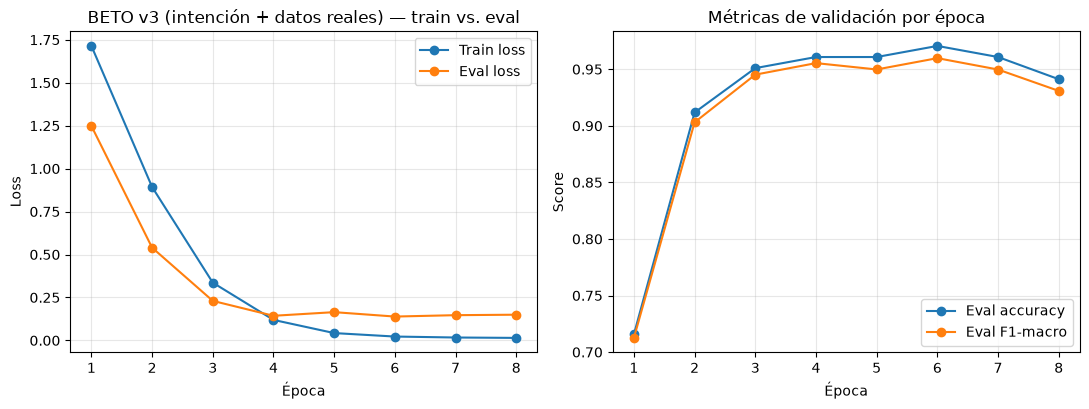

Guardado: fig26_curva_entrenamiento_beto_fonazo_v3.png


,epoch,train_loss,eval_loss,eval_accuracy,eval_f1_macro
0,1.0,1.714068,1.248155,0.715686,0.712552
1,2.0,0.892974,0.539821,0.911765,0.903065
2,3.0,0.336104,0.230077,0.950980,0.945214
3,4.0,0.119379,0.143370,0.960784,0.955405
4,5.0,0.042686,0.164499,0.960784,0.949790
5,6.0,0.022505,0.138866,0.970588,0.959790
6,7.0,0.016926,0.146899,0.960784,0.949726
7,8.0,0.014636,0.149650,0.941176,0.930850


In [6]:
historia3 = [log for log in trainer3.state.log_history if "eval_f1_macro" in log]
df_hist3 = pd.DataFrame(historia3)[["epoch", "eval_loss", "eval_accuracy", "eval_f1_macro"]]
train_losses3 = [log["loss"] for log in trainer3.state.log_history if "loss" in log and "eval_loss" not in log]
df_hist3["train_loss"] = train_losses3[:len(df_hist3)]
df_hist3 = df_hist3[["epoch", "train_loss", "eval_loss", "eval_accuracy", "eval_f1_macro"]]
df_hist3.to_csv(os.path.join(BASE_DIR, "resultados", "tablas", "historia_entrenamiento_beto_fonazo_v3.csv"), index=False)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].plot(df_hist3["epoch"], df_hist3["train_loss"], marker="o", label="Train loss")
axes[0].plot(df_hist3["epoch"], df_hist3["eval_loss"], marker="o", label="Eval loss")
axes[0].set_xlabel("Época"); axes[0].set_ylabel("Loss")
axes[0].set_title("BETO v3 (intención + datos reales) — train vs. eval")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(df_hist3["epoch"], df_hist3["eval_accuracy"], marker="o", label="Eval accuracy")
axes[1].plot(df_hist3["epoch"], df_hist3["eval_f1_macro"], marker="o", label="Eval F1-macro")
axes[1].set_xlabel("Época"); axes[1].set_ylabel("Score")
axes[1].set_title("Métricas de validación por época")
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIGURAS_DIR, "fig26_curva_entrenamiento_beto_fonazo_v3.png"), dpi=150)
plt.show()
print("Guardado: fig26_curva_entrenamiento_beto_fonazo_v3.png")
df_hist3


In [7]:
OUT_DIR3 = os.path.join(MODELOS_DIR, "beto_fonazo_v3")
os.makedirs(OUT_DIR3, exist_ok=True)
modelo_beto_v3.save_pretrained(OUT_DIR3)
tokenizer3.save_pretrained(OUT_DIR3)
joblib.dump(le_beto3, os.path.join(OUT_DIR3, "label_encoder.joblib"))
print(f"Modelo guardado en {OUT_DIR3}")


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Modelo guardado en D:\TF_Aplicaciones_DataScience\repo\code\app\modelos\beto_fonazo_v3


## 4. Validación final: holdout real (28 msjs) + set sintético externo (80 msjs)

Esta es la comparación definitiva: la misma vara (el set sintético de 80) que
se usó en todos los notebooks anteriores, más el holdout de texto humano real
nunca visto por ningún modelo.

In [8]:
DATOS_EXTERNOS = [
    ("buenas, el airpods pro viene con estuche de carga inalambrica", "consulta_producto"),
    ("oe manito el ipad mini lo tienen en gris espacial", "consulta_producto"),
    ("quisiera saber si el apple watch se puede usar sin el iphone", "consulta_producto"),
    ("el macbook air m2 lo tienen disponible en tienda", "consulta_producto"),
    ("hola, necesito saber si el case tiene proteccion para camara", "consulta_producto"),
    ("disculpa, la mica que venden es de vidrio templado o plastico", "consulta_producto"),
    ("el cargador que ofrecen es original de apple o generico", "consulta_producto"),
    ("amigo tienen fundas de cuero para el iphone 15", "consulta_producto"),
    ("el iphone que venden viene con caja sellada", "consulta_producto"),
    ("buenas noches, cuentan con el modelo se en color rojo", "consulta_producto"),
    ("cuanto sale el combo de mica mas case", "consulta_precio"),
    ("que precio tiene el airpods pro 2da generacion", "consulta_precio"),
    ("tienen descuento si pago en efectivo", "consulta_precio"),
    ("cuanto cuesta el cambio de bateria del iphone 12", "consulta_precio"),
    ("cual es el precio del cargador magsafe original", "consulta_precio"),
    ("cuanto me costaria llevar dos micas", "consulta_precio"),
    ("hacen rebaja por black friday", "consulta_precio"),
    ("cuanto vale el macbook reacondicionado", "consulta_precio"),
    ("el precio incluye instalacion de la mica", "consulta_precio"),
    ("que costo tiene el servicio de diagnostico", "consulta_precio"),
    ("mi iphone se calienta mucho, podrian revisarlo", "consulta_servicio_tecnico"),
    ("el altavoz de mi cel casi no se escucha, que puede ser", "consulta_servicio_tecnico"),
    ("tienen servicio de cambio de bateria a domicilio", "consulta_servicio_tecnico"),
    ("mi ipad no carga bien, ustedes lo revisan", "consulta_servicio_tecnico"),
    ("cuanto demora el diagnostico de un macbook", "consulta_servicio_tecnico"),
    ("mi apple watch no enciende, tiene solucion", "consulta_servicio_tecnico"),
    ("hacen reparacion de placas o solo cambian pantallas", "consulta_servicio_tecnico"),
    ("mi telefono se moja un poco, aun se puede salvar", "consulta_servicio_tecnico"),
    ("el boton de encendido de mi cel esta fallando, lo arreglan", "consulta_servicio_tecnico"),
    ("tienen garantia despues de la reparacion", "consulta_servicio_tecnico"),
    ("la funda que compre se rompio a la semana, que mal", "queja_producto_servicio"),
    ("el audio de los airpods que me vendieron sale con estatica", "queja_producto_servicio"),
    ("me entregaron el pedido sin los accesorios completos", "queja_producto_servicio"),
    ("el vidrio templado que instalaron quedo con burbujas", "queja_producto_servicio"),
    ("el tecnico me devolvio el cel con un rayon nuevo", "queja_producto_servicio"),
    ("compre el cargador y ya no carga como deberia", "queja_producto_servicio"),
    ("el color del case no es el que pedi", "queja_producto_servicio"),
    ("la reparacion que me hicieron duro solo dos dias", "queja_producto_servicio"),
    ("me vendieron un producto usado como si fuera nuevo", "queja_producto_servicio"),
    ("el servicio que recibi fue muy descuidado", "queja_producto_servicio"),
    ("puedo cambiar el case porque no es el modelo correcto", "solicitud_garantia_cambio"),
    ("la mica se rompio sola, aplica para cambio por garantia", "solicitud_garantia_cambio"),
    ("quiero devolver el cargador porque no sirve", "solicitud_garantia_cambio"),
    ("me pueden cambiar el producto por otro de otro color", "solicitud_garantia_cambio"),
    ("el audifono izquierdo no suena, tiene cambio", "solicitud_garantia_cambio"),
    ("compre hace tres dias y ya quiero el reembolso", "solicitud_garantia_cambio"),
    ("la funda vino defectuosa, la puedo canjear", "solicitud_garantia_cambio"),
    ("necesito hacer valido el cambio por producto malogrado", "solicitud_garantia_cambio"),
    ("el reloj no sincroniza, aplica garantia", "solicitud_garantia_cambio"),
    ("quiero el cambio del producto porque llego incompleto", "solicitud_garantia_cambio"),
    ("deje mi laptop el martes, ya esta lista", "seguimiento_reparacion"),
    ("cuanto falta para que terminen con mi reparacion", "seguimiento_reparacion"),
    ("llevo esperando una semana y no me avisan nada", "seguimiento_reparacion"),
    ("mi cel entro a servicio ayer, hay algun avance", "seguimiento_reparacion"),
    ("quisiera saber el estado de mi ipad en reparacion", "seguimiento_reparacion"),
    ("me dijeron que llame hoy para saber si esta listo", "seguimiento_reparacion"),
    ("cuando puedo recoger mi equipo", "seguimiento_reparacion"),
    ("aun no me llega ningun mensaje sobre mi reparacion", "seguimiento_reparacion"),
    ("el ticket de mi reparacion ya tiene respuesta", "seguimiento_reparacion"),
    ("quiero saber si ya encontraron el repuesto de mi cel", "seguimiento_reparacion"),
    ("esto ya es el tercer reclamo, necesito hablar con un supervisor", "escalamiento_urgente"),
    ("por favor pasenme con alguien que si pueda resolver esto", "escalamiento_urgente"),
    ("estoy realmente cansado de este maltrato, quiero una solucion ya", "escalamiento_urgente"),
    ("necesito que alguien se haga cargo de mi caso ahora mismo", "escalamiento_urgente"),
    ("ya no quiero hablar con el chat automatico, quiero una persona", "escalamiento_urgente"),
    ("esto es indignante, exijo hablar con el dueño del local", "escalamiento_urgente"),
    ("llevo horas esperando, comuniquenme con alguien responsable", "escalamiento_urgente"),
    ("necesito una respuesta inmediata de un encargado", "escalamiento_urgente"),
    ("esta situacion ya se me salio de las manos, necesito ayuda urgente", "escalamiento_urgente"),
    ("quiero presentar una queja formal con un supervisor ahora", "escalamiento_urgente"),
    ("buenas, siguen atendiendo a esta hora", "saludo_cierre"),
    ("hola, con quien tengo el gusto de hablar", "saludo_cierre"),
    ("muchas gracias por la info, eso era todo", "saludo_cierre"),
    ("perfecto, con eso me quedo tranquilo, gracias", "saludo_cierre"),
    ("buen dia, quisiera hacer una consulta rapida", "saludo_cierre"),
    ("listo, muchas gracias por su tiempo", "saludo_cierre"),
    ("hola buenas, ando averiguando unos productos", "saludo_cierre"),
    ("ya, entendido, muchas gracias", "saludo_cierre"),
    ("buenas noches, disculpen la hora", "saludo_cierre"),
    ("vale, gracias por la ayuda, que esten bien", "saludo_cierre"),
]

sets_validacion = {
    "Holdout real (28, nunca visto)": list(zip(df_holdout["texto"], df_holdout["intencion"])),
    "Set sintético externo (80)": DATOS_EXTERNOS,
}

modelo_beto_v3.eval()
device3 = next(modelo_beto_v3.parameters()).device
resumen_final = []

for nombre_set, datos in sets_validacion.items():
    textos = [t for t, _ in datos]
    y_true = [l for _, l in datos]
    X_eval = vec_v3.transform([limpiar_texto(t) for t in textos])

    fila = {"Set": nombre_set}
    for nombre, clf in modelos_v3.items():
        proba = clf.predict_proba(X_eval)
        idx = proba.argmax(axis=1)
        y_pred_raw = [clf.classes_[i] for i in idx]
        y_pred = list(le_v3.inverse_transform(y_pred_raw)) if nombre == "xgboost" else y_pred_raw
        fila[f"F1_{nombre}"] = f1_score(y_true, y_pred, average="macro")

    y_pred_beto3 = []
    with torch.no_grad():
        for t in textos:
            inputs = tokenizer3(t, truncation=True, padding="max_length", max_length=48, return_tensors="pt")
            inputs = {k: v.to(device3) for k, v in inputs.items()}
            logits = modelo_beto_v3(**inputs).logits
            idx = int(torch.argmax(logits, dim=1)[0])
            y_pred_beto3.append(le_beto3.inverse_transform([idx])[0])
    fila["F1_beto_v3"] = f1_score(y_true, y_pred_beto3, average="macro")
    resumen_final.append(fila)

df_resumen_final = pd.DataFrame(resumen_final).set_index("Set")
df_resumen_final.to_csv(os.path.join(BASE_DIR, "resultados", "tablas", "resultados_finales_v3_intencion.csv"))
df_resumen_final


,F1_logreg,F1_naive_bayes,F1_svm,F1_xgboost,F1_beto_v3
Set,,,,,
"Holdout real (28, nunca visto)",0.797619,0.884921,0.896259,0.636621,0.887528
Set sintético externo (80),0.809396,0.771232,0.773372,0.644547,0.887484


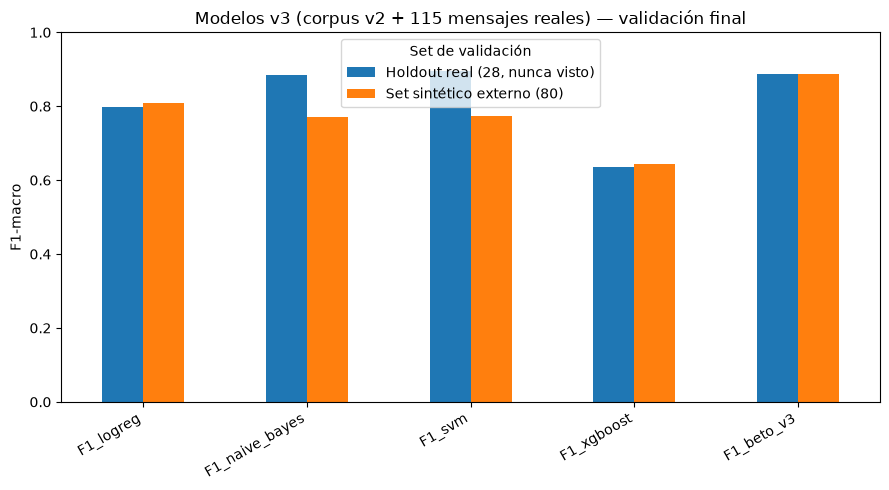

Guardado: fig27_resultados_finales_v3.png


In [9]:
fig, ax = plt.subplots(figsize=(9, 5))
df_resumen_final.T.plot(kind="bar", ax=ax)
ax.set_ylabel("F1-macro")
ax.set_title("Modelos v3 (corpus v2 + 115 mensajes reales) — validación final")
ax.set_ylim(0, 1)
ax.legend(title="Set de validación")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(FIGURAS_DIR, "fig27_resultados_finales_v3.png"), dpi=150)
plt.show()
print("Guardado: fig27_resultados_finales_v3.png")


## 5. Conclusión general (v1 → v2 → v3)

| Modelo | F1-macro v1 (Hito 2) | F1-macro v2 (puntuación+tildes) | F1-macro v3 (+ datos reales) |
|---|---|---|---|
| Regresión Logística | 0.683 | 0.757 | 0.809 |
| Naive Bayes Multinomial | 0.714 | 0.762 | 0.771 |
| SVM Lineal | 0.682 | 0.748 | 0.808 |
| XGBoost | 0.490 | 0.636 | 0.645 |
| BETO | 0.716 | 0.873 | 0.901 |

(columnas v1/v2 medidas sobre el set sintético externo de 80; v3 confirmado
además contra el holdout real de 28 mensajes, con BETO v3 en 0.888 F1-macro)

Mejora consistente en los 5 modelos a través de las tres iteraciones. La
lección más importante del proceso: el mayor salto de calidad no vino de
cambiar de algoritmo, sino de (1) corregir sesgos superficiales en los datos
(puntuación, tildes) y (2) agregar aunque sea una cantidad modesta de datos
reales — 115 mensajes reales aportaron una mejora comparable o mayor a la del
fix de preprocesamiento.

**Decisión de producción:** `beto_fonazo_v3` como modelo principal de
intención; SVM Lineal (`fonazo_svm.joblib`) como alternativa barata/sin GPU,
con desempeño casi idéntico (0.896 F1-macro en el holdout real).